In [ ]:
# =============================================================================
# MIT License
#
# Copyright (c) 2025 Jason Coleman
# UF MBI Microscopy Core / NeuroMicroscopy Co-op
# University of Florida
# jcoleman@ufl.edu
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.
# =============================================================================

# Notebook: image_hist&qc_scanimage.ipynb
# Version: 0.0.1
# Date: 2026-02-11

# Description:
#   Processing of 2 2-channel ScanImage TIFF ZT (timelapse) stacks to interactively plot and inspect image data
#       (e.g., histograms and quality-control metrics)


# Changelog:
#   0.0.1 (2026-02-11) – Modified from get_tif_info_scanimage.ipynb
  
# NOTE: This code is intended for research and educational use.
# Please cite or acknowledge the UF MBI Microscopy Core where appropriate.

# **License:** MIT  
# © 2026 Jason Coleman, UF MBI Microscopy Core / NeuroMicroscopy Co-op  
# University of Florida — jcoleman@ufl.edu


In [61]:
# Import ScanImage tif files (single-file)

# Works for T- or Z-only stacks

import numpy as np
import os
from pathlib import Path
import json
import socket
import tifffile # !pip install tifffile
import platform
import re
from datetime import datetime
import matplotlib.pyplot as plt

import pandas as pd

# Path to your ScanImage stack (replace 'text' with your directory
# path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling/ZT20 TIFs'
path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling'

# Name of the TIF file to import
# tif_filename1 = 'ZT20_25x_930_t0_area1_00001.tif' #'ZT20_25x_930_t5_area1_00001.tif'
# tif_filename1 = 'ZT20_25x_930_t5_area2_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area2_00001.tif' #'ZT20_25x_1100_t5_area1_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area1_00001.tif'
tif_filename1 = 'T1800_25x3x_930nm_area01_00001.tif' # (T,C,X,Y)
tif_filename2 = 'T1800_25x3x_1100nm_area01_00001.tif' # (T,C,X,Y)

tif_file1 = os.path.join(
    path, 
    tif_filename1
)
tif_file2 = os.path.join(
    path, 
    tif_filename2
)

tif_data1 = tifffile.imread(tif_file1)
tif_data2 = tifffile.imread(tif_file2)

print(f'Pathname: {path}')
print(f'Filenames: {tif_filename1} | {tif_filename2}')
print(f'File1 shape: (e.g. T, C, Y, X): {tif_data1.shape}')
print(f'File2 shape: (e.g. T, C, Y, X): {tif_data2.shape}')

# NEXT STEPS - Run the next cell for 2-channel ZT data OR skip it and run the one after for T data


Pathname: /Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling
Filenames: T1800_25x3x_930nm_area01_00001.tif | T1800_25x3x_1100nm_area01_00001.tif
File1 shape: (e.g. T, C, Y, X): (1800, 2, 512, 512)
File2 shape: (e.g. T, C, Y, X): (1800, 2, 512, 512)


In [62]:
# Read in Channel1 (green) and Channel2 (red) from 2 TIF files, recombine for green-red
# import tifffile as tiff
# import numpy as np

def load_tcyx(path):
    data = tiff.imread(path)
    if data.ndim != 4:
        raise ValueError(f"Expected 4D (T,C,Y,X) but got {data.shape}")
    return data

def recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=None):
    if tif1_ch1.shape != tif2_ch2.shape:
        msg = (
            f"SKIP: shape mismatch "
            f"Ch1 {tif1_ch1.shape} vs Ch2 {tif2_ch2.shape}"
        )
        if filename:
            msg += f" | file={filename}"
        print(msg)
        return None  # sentinel → skip downstream

    return np.stack([tif1_ch1, tif2_ch2], axis=2)  # (T,2,Y,X)

# tif1 = load_tcyx(tif_file1)  # (Z,T,C,Y,X)
# tif2 = load_tcyx(tif_file2)  # (Z,T,C,Y,X)

# Extract desired channels
tif1_ch1 = tif_data1[:, 0, :, :]   # (Z,T,Y,X)
tif2_ch2 = tif_data2[:, 1, :, :]   # (Z,T,Y,X)
# tif2_ch2 = tif2[0:11, :, 1, :, :]   # mismatch for ch1-ch2 Z-correlation tests (Z,T,Y,X)

# # Validate shape compatibility
# if tif1_ch1.shape != tif2_ch2.shape:
#     raise ValueError(f"Shape mismatch: {tif1_ch1.shape} vs {tif2_ch2.shape}")

# # Recombine into new "tif_data" with 2 channels
# tif_data = np.stack([tif1_ch1, tif2_ch2], axis=2)  # (Z,T,C,Y,X)
# tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=tif_file1)

# if tif_data is None:
#     # Optionally log this somewhere
#     skipped_files.append(tif_file1)
#     skip_log.append({
#         "file_ch1": tif1_path,
#         "file_ch2": tif2_path,
#         "shape_ch1": tif1_ch1.shape,
#         "shape_ch2": tif2_ch2.shape,
#         "reason": "Z/T/Y/X mismatch"
#     })
#     return  # move to next file
skipped_files = []
skip_log = []
tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2)

if tif_data is None:
    skipped_files.append(path)
    skip_log.append({
        "file_ch1": tif_file1,
        "file_ch2": tif_file2,
        "shape_ch1": tif1_ch1.shape,
        "shape_ch2": tif2_ch2.shape,
        "reason": "T/Y/X mismatch"
    })

    print(skipped_files)
    print(skip_log)
else:
    print("FUTURE: run_qc(tif_data)")

    # Now your existing QC code works as-is
    tif_data = np.transpose(tif_data, (0, 2, 1, 3))  # (T,C,Y,X)
    T, C, Y, X = tif_data.shape
    print(T,C,X,Y)
    print(f'Ch1 from {tif_filename1} + Ch2 from {tif_filename2} combined into single tif_data')

FUTURE: run_qc(tif_data)
1800 2 512 512
Ch1 from T1800_25x3x_930nm_area01_00001.tif + Ch2 from T1800_25x3x_1100nm_area01_00001.tif combined into single tif_data


In [64]:
# Average across T for every Z
    # (Eg for ZT20*.tif file, 20 T frames will be averaged into a single plane/2D image at each Z)
    # Calculate the average intensity for each Z-plane (17 total)
    # across all time frames (20 total) per plane.
    # Formula: Z_avg[i] = mean(Frames[i, 0:20])

    # Process: Z-Average Projection
    # Input:  (Z=17, T=20, Y, X)
    # Output: (Z=17, Y, X) 
    # Expression: Avg_Zi = Σ(T_0...T_19) / 20


# tif_Zavg = tif_data.mean(axis=1)  # (Z, C, Y, X)
# print(tif_Zavg.shape)

# T, C, Y, X = tif_data.shape
bin_size = 30 # number of T frames to average (30 would go from ~30fps to ~1fps)
# T_trim = (T // bin_size) * bin_size
# tif_trim = tif_data[:T_trim, :, :, :]
# print(tif_trim.shape)

# tslice_middle = int(len(tif_trim)/2)
# tsliceNum = tslice_middle
# print(f"Plot Z-slice#: {tsliceNum}")
# T_trim

tif_binned = tif_data.reshape(
    T_trim // bin_size,
    bin_size,
    C,
    Y,
    X
).mean(axis=1)

print(tif_binned.shape)

tslice_middle = int(len(tif_binned)/2)
tsliceNum = tslice_middle
print(f"Plot T-frame#: {tsliceNum}")

(60, 2, 512, 512)
Plot T-frame#: 30


In [65]:
# Z data averaged over T (e.g. (Z,C,Y,X))
# use for Z T-avg'ed data (ie Avg_Zi = Σ(T_0...T_19) / 20)

channel_1_data = tif_binned[:, 0, :, :]  # shape: (33, 512, 512)
channel_2_data = tif_binned[:, 1, :, :]  # shape: (33, 512, 512)

print(f"Channel 1   shape: {channel_1_data.shape}")
print(f"Channel 2   shape: {channel_2_data.shape}")

# Transpose to (Y, X, Z) if needed for your code
channel_1_data = np.transpose(channel_1_data, (1, 2, 0))  # shape: (512, 512, 33)
channel_2_data = np.transpose(channel_2_data, (1, 2, 0))  # shape: (512, 512, 33)

print(f"Channel 1 reshape: {channel_1_data.shape}")
print(f"Channel 2 reshape: {channel_2_data.shape}")

# zsliceNum = 10 # Optional value for plotting below, replaces the middle value from above
# zsliceNum

Channel 1   shape: (60, 512, 512)
Channel 2   shape: (60, 512, 512)
Channel 1 reshape: (512, 512, 60)
Channel 2 reshape: (512, 512, 60)


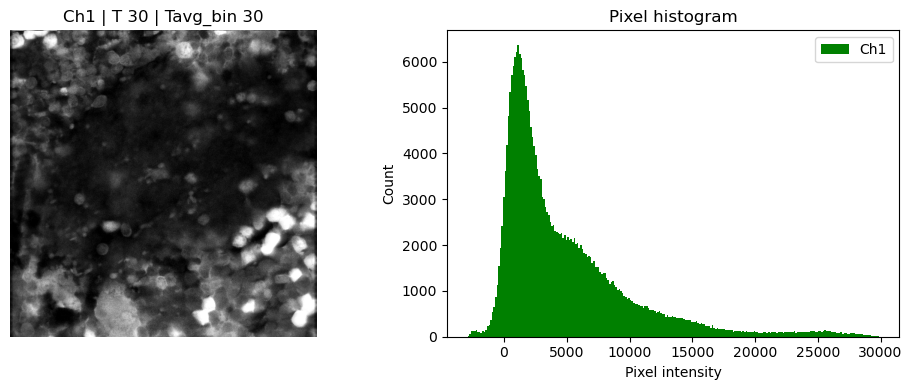

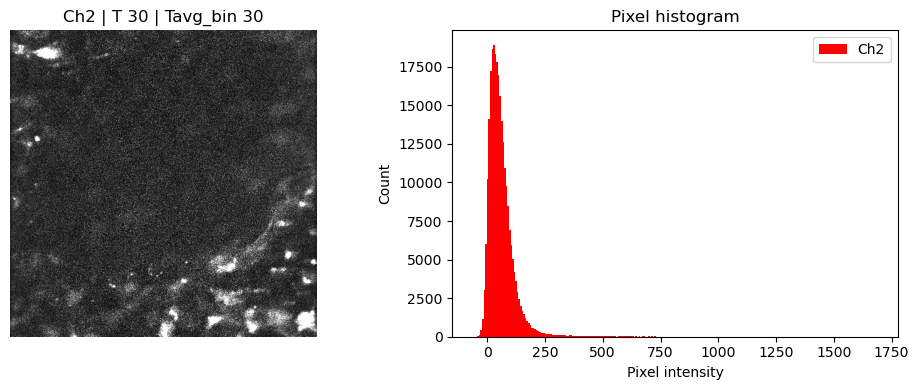

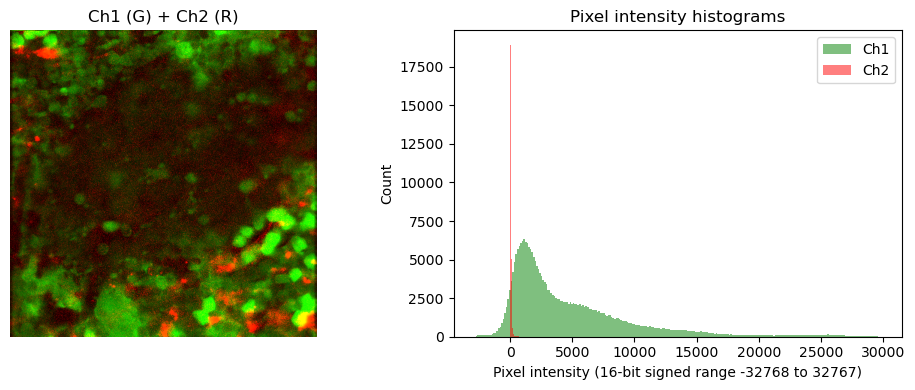

In [66]:
# Sanity check the channels - w/ histograms and ch1+ch2 overlay

# import numpy as np
# import matplotlib.pyplot as plt

def plot_slice_histogram(img, histcolor, zsliceNum=0, frame='Avg', channel='signal'):
    # img = channel_1_data[:, :, frame]
    pixels = img.ravel()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Image
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    axes[0].imshow(img, cmap='gray',
               vmin=vmin,
               vmax=vmax)
    #axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'{channel} | T {zsliceNum} | Tavg_bin {bin_size}')
    axes[0].axis('off')
    
    # Histogram
    # axes[1].hist(pixels, bins=256, density=True, color=histcolor)
    axes[1].hist(pixels, bins=256, density=False, color=histcolor, label=channel)
    axes[1].set_xlabel('Pixel intensity')
    # axes[1].set_ylabel('Probability density')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel histogram')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_overlay_and_hist(img1, img2, zsliceNum=0, frame=None,
                          bins=256, alpha=0.5, Saturation=32767):
    """
    img1, img2: (Y, X) arrays for channel 1 and channel 2
    """

    # Build RGB overlay (normalize for display only)
    # def norm(im):
    #     im = im.astype(float)
    #     return (im - im.min()) / (im.max() - im.min() + 1e-9)
    def norm(im, pmin=1, pmax=99):
        im = im.astype(float)
        vmin = np.percentile(im, pmin)
        vmax = np.percentile(im, pmax)
        return np.clip((im - vmin) / (vmax - vmin + 1e-9), 0, 1)

    rgb = np.zeros((*img1.shape, 3))
    rgb[..., 1] = norm(img1)   # green
    rgb[..., 0] = norm(img2)   # red

    # Flatten pixels
    p1 = img1.ravel()
    p2 = img2.ravel()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ---- Overlay image ----
    axes[0].imshow(rgb)
    title = "Ch1 (G) + Ch2 (R)"
    if zsliceNum is not None and frame is not None:
        title += f" | T {zsliceNum} | Tavg_bin {bin_size}"
    axes[0].set_title(title)
    axes[0].axis('off')

    # ---- Overlaid histograms ----
    axes[1].hist(p1, bins=bins, density=False,
                 color='green', alpha=alpha, label='Ch1')
    axes[1].hist(p2, bins=bins, density=False,
                 color='red', alpha=alpha, label='Ch2')

    axes[1].set_xlabel(f'Pixel intensity (16-bit signed range -32768 to 32767)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel intensity histograms')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def preprocess_background(img, bg_pctle=5, norm_pctle=99):
    # perform background subtraction and normalization
    # 1. Keep raw int16 data untouched
    img_raw = img
    
    # 2. Background subtract (robust)
    bg = np.percentile(img_raw, bg_pctle)
    img_bg = img_raw - bg
    
    # 3. (Optional) Normalize to reference
    img_norm = img_bg / np.percentile(img_bg, norm_pctle)

    return img_bg, img_norm

# run the functions here
# frame = 5 # select T frame
# img_chan1 = channel_1_data[:, :, frame]
# img_chan2 = channel_2_data[:, :, frame]

# Need to distinguish Z, T etc explicitlu hehre
img_chan1 = channel_1_data[:, :, tsliceNum]
img_chan2 = channel_2_data[:, :, tsliceNum]

img_chan1_background, img_chan1_normalized = preprocess_background(img_chan1, bg_pctle=5, norm_pctle=99)
img_chan2_background, img_chan2_normalized = preprocess_background(img_chan2, bg_pctle=5, norm_pctle=99)

plot_slice_histogram(img_chan1_background, 'green', tsliceNum, channel='Ch1')
plot_slice_histogram(img_chan2_background, 'red', tsliceNum, channel='Ch2')
plot_overlay_and_hist(img_chan1_background, img_chan2_background,
                      zsliceNum=tsliceNum, frame=None)


In [67]:
print(tif_data.dtype)
print("min:", tif_data.min())
print("max:", tif_data.max())

print(tif_binned.dtype)
print("min:", tif_binned.min())
print("max:", tif_binned.max())

int16
min: -3484
max: 32767
float64
min: -91.13333333333334
max: 32767.0


In [68]:
"""
Notes / knobs you’ll likely tweak

If your Ch2 medians routinely exceed 12k (bright dyes / high gain), bump:

ylim_med_ch2 = (0, 20000) (or 30000)

If your IQR is usually >2000 (dense structure), bump:

ylim_iqr_ch2 = (0, 4000)

If you want the guideline lines to be bands instead of individual lines (shaded zones), I can swap to axhspan().
"""
# QC thresholds (recap, encoded once)
# ---- QC thresholds (int16 ScanImage-style) ----
SAT = 32767

# Median (intensity)
MED_DIM = 500
MED_GOOD_LO, MED_GOOD_HI = 1000, 8000
MED_HOT_HI = 15000

# IQR (contrast / structure)
IQR_LOW = 50
IQR_GOOD_LO, IQR_GOOD_HI = 100, 800
IQR_CEIL = 2000

# Saturation fraction
SAT_WARN = 0.01     # 1%
SAT_BAD  = 0.05     # 5%


In [69]:
# # Helper for guide lines - optional to the final set of plots below
# Basic analysis using median, IQR, and plotting saturation fractions
# More refined analysis comes after
#           - for quick screening/flagging files
#           - impt for quantitative analysis down the road
# def add_guides(a, guides):
#     """
#     guides: list of (y, linestyle, alpha, label)
#     """
#     for y, ls, alpha, label in guides:
#         a.axhline(y, ls=ls, alpha=alpha)
#         if label:
#             a.text(
#                 0.98, y, label,
#                 transform=a.get_yaxis_transform(),
#                 ha="right", va="bottom",
#                 fontsize=8, alpha=0.85
#             )

# # Figure: 3 QC rows + explanation row
# fig, ax = plt.subplots(
#     4, 2,
#     figsize=(13, 11),
#     sharex=True,
#     gridspec_kw={"height_ratios": [1, 1, 1, 0.55]}
# )

# # Row 1 — Median intensity
# ax[0,0].plot(med1, lw=1.8)
# ax[0,1].plot(med2, lw=1.8)

# ax[0,0].set_title("Channel 1 QC (T-avg per Z)")
# ax[0,1].set_title("Channel 2 QC (T-avg per Z)")
# ax[0,0].set_ylabel("Median intensity")

# median_guides = [
#     (MED_DIM, "--", 0.35, "dim"),
#     (MED_GOOD_LO, "-", 0.25, "good lo"),
#     (MED_GOOD_HI, "-", 0.25, "good hi"),
#     (MED_HOT_HI, "--", 0.35, "risky"),
# ]
# # Good median band
# ax[0,0].axhspan(
#     MED_GOOD_LO, MED_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )
# ax[0,1].axhspan(
#     MED_GOOD_LO, MED_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )


# add_guides(ax[0,0], median_guides)
# add_guides(ax[0,1], median_guides)

# # ax[0,0].set_ylim(0, 12000)
# # ax[0,1].set_ylim(0, 12000)


# # Row 2 — IQR
# ax[1,0].plot(iqr1, lw=1.8)
# ax[1,1].plot(iqr2, lw=1.8)

# ax[1,0].set_ylabel("IQR (Q75–Q25)")

# iqr_guides = [
#     (IQR_LOW, "--", 0.35, "low"),
#     (IQR_GOOD_LO, "-", 0.25, "good lo"),
#     (IQR_GOOD_HI, "-", 0.25, "good hi"),
#     (IQR_CEIL, "--", 0.25, "ceiling"),
# ]
# ax[1,0].axhspan(
#     IQR_GOOD_LO, IQR_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )
# ax[1,1].axhspan(
#     IQR_GOOD_LO, IQR_GOOD_HI,
#     color='green', alpha=0.08, zorder=0
# )

# add_guides(ax[1,0], iqr_guides)
# add_guides(ax[1,1], iqr_guides)

# # ax[1,0].set_ylim(0, IQR_CEIL)
# # ax[1,1].set_ylim(0, IQR_CEIL)


# # Row 3 — Saturation fraction (critical)
# ax[2,0].plot(sat1, lw=1.8)
# ax[2,1].plot(sat2, lw=1.8)

# ax[2,0].set_ylabel("Saturation fraction")
# ax[2,0].text(
#     0.02, 0.9, f"SAT = {SAT}",
#     transform=ax[2,0].transAxes,
#     fontsize=9
# )

# # Warning / failure lines
# sat_guides = [
#     (SAT_WARN, "--", 0.5, "warn (1%)"),
#     (SAT_BAD,  "--", 0.7, "bad (5%)"),
# ]

# add_guides(ax[2,0], sat_guides)
# add_guides(ax[2,1], sat_guides)

# # ax[2,0].set_ylim(0, 0.1)
# # ax[2,1].set_ylim(0, 0.1)

# # Shared X, grids, polish
# xmax = Z - 1
# for a in ax[0:3, :].flat:
#     a.set_xlim(0, xmax)
#     a.grid(True, alpha=0.2)

# ax[2,0].set_xlabel("Z index")
# ax[2,1].set_xlabel("Z index")

# # Row 4 — Explanation panel (no axes)
# for c in range(2):
#     ax[3,c].axis("off")

# explain = (
#     "QC interpretation (int16 ScanImage-style)\n"
#     "Median: <500 dim | 1000–8000 good | 8000–15000 hot | >15000 clipping risk\n"
#     "IQR: <50 low contrast/focus | 100–800 healthy structure | >800 very structured\n"
#     "Saturation: >1% warning | >5% unacceptable (power/gain too high)\n"
#     "Best practice: keep fixed axes across files so depth-related failures pop out."
# )

# ax[3,0].text(
#     0.0, 0.95, explain,
#     ha="left", va="top",
#     fontsize=10
# )

# plt.tight_layout()
# plt.show()

In [70]:
"""
How to interpret these (especially for tdTomato)

For a sparse red channel:

If P5 rises with Z but P99 and top_mean are flat-ish
→ baseline/offset drift or depth-dependent background dominates.

If P99/top_mean rise with Z too
→ true depth-dependent detection/power or real biological increase.

If P99−P5 rises but bright_frac stays constant
→ objects get brighter but occupy similar area.

If bright_frac rises
→ more red-positive area at those Zs (could be structure density or focus band).

per Z, per channel:
Baseline / offset
p5 (or p10)

Signal-sensitive
p50 (median)
p95, p99

Contrast
dr = p99 - p5

Clipping
sat (>= SAT)
near_sat (>= SAT - margin)

Sparse-aware
top_mean: mean of top q% pixels (e.g., 0.5% brightest)
bright_frac: fraction of pixels above an adaptive threshold (e.g., > p99)
"""

# import numpy as np
# import matplotlib.pyplot as plt

SAT = 32767

def qc_per_z_extended(channel_idx, *,
                      p_lo=5, p_hi1=95, p_hi2=99,
                      top_frac=0.005,          # top 0.5%
                      near_sat_margin=500,      # counts below SAT
                      bright_thresh_mode="p99"  # "p99" or "p995" or numeric
                     ):
    """
    tif_data expected shape: (Z, T, C, Y, X)
    Returns dict of per-Z metrics.
    """
    Z = tif_data.shape[0]   # ← derive from data, not global
    
    med = np.zeros(Z)
    iqr = np.zeros(Z)
    sat = np.zeros(Z)

    p5 = np.zeros(Z)
    p50 = np.zeros(Z)
    p95 = np.zeros(Z)
    p99 = np.zeros(Z)
    dr = np.zeros(Z)

    near_sat = np.zeros(Z)

    top_mean = np.zeros(Z)
    bright_frac = np.zeros(Z)

    for z in range(Z):
        img = tif_data[z, channel_idx, :, :].mean(axis=0)  # (Y,X)
        px = img.ravel()

        # percentiles
        p5[z]  = np.percentile(px, p_lo)
        p50[z] = np.percentile(px, 50)
        p95[z] = np.percentile(px, p_hi1)
        p99[z] = np.percentile(px, p_hi2)
        dr[z]  = p99[z] - p5[z]

        # legacy metrics (keep)
        med[z] = p50[z]
        iqr[z] = np.percentile(px, 75) - np.percentile(px, 25)
        sat[z] = np.mean(px >= SAT)
        near_sat[z] = np.mean(px >= (SAT - near_sat_margin))

        # top fraction mean (sparse-signal proxy)
        k = max(1, int(np.floor(top_frac * px.size)))
        # partition is faster than full sort
        topk = np.partition(px, -k)[-k:]
        top_mean[z] = np.mean(topk)

        # bright fraction above threshold
        if isinstance(bright_thresh_mode, (int, float)):
            thr = bright_thresh_mode
        else:
            if bright_thresh_mode == "p99":
                thr = p99[z]
            elif bright_thresh_mode == "p995":
                thr = np.percentile(px, 99.5)
            elif bright_thresh_mode == "p999":
                thr = np.percentile(px, 99.9)
            else:
                thr = p99[z]
        bright_frac[z] = np.mean(px > thr)

    return {
        "p5": p5, "p50": p50, "p95": p95, "p99": p99,
        "dr": dr,
        "iqr": iqr,
        "sat": sat, "near_sat": near_sat,
        "top_mean": top_mean,
        "bright_frac": bright_frac,
    }

qc1 = qc_per_z_extended(0)  # Ch1
qc2 = qc_per_z_extended(1)  # Ch2

print(f'Saturation set at {SAT} & quality control function(s) loaded. Run the next cell...')

Saturation set at 32767 & quality control function(s) loaded. Run the next cell...


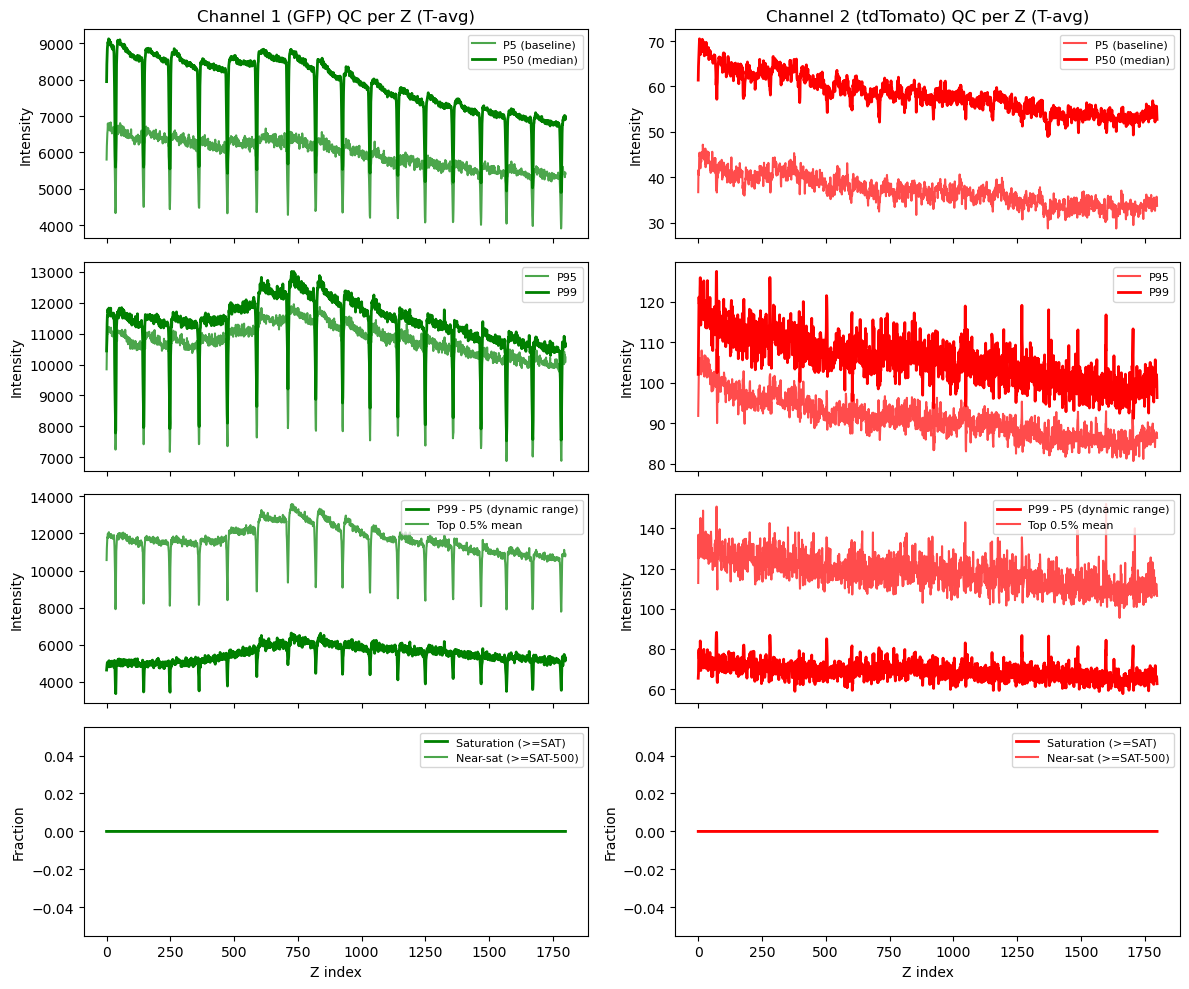

In [71]:
# Plotting: a “high-value” QC figure (4 rows × 2 cols)
# This replaces your 3×2 with something more informative for sparse channels.
fig, ax = plt.subplots(4, 2, figsize=(12, 10), sharex=True)

def plot_channel(col, qc, color, title):
    # Row 1: Baseline + central tendency
    ax[0, col].plot(qc["p5"],  color=color, alpha=0.7, label="P5 (baseline)")
    ax[0, col].plot(qc["p50"], color=color, lw=2, label="P50 (median)")
    ax[0, col].set_title(title)
    ax[0, col].set_ylabel("Intensity")
    ax[0, col].legend(fontsize=8)

    # Row 2: Signal-sensitive percentiles
    ax[1, col].plot(qc["p95"], color=color, alpha=0.7, label="P95")
    ax[1, col].plot(qc["p99"], color=color, lw=2, label="P99")
    ax[1, col].set_ylabel("Intensity")
    ax[1, col].legend(fontsize=8)

    # Row 3: Contrast + sparse-signal proxy
    ax[2, col].plot(qc["dr"],       color=color, lw=2, label="P99 - P5 (dynamic range)")
    ax[2, col].plot(qc["top_mean"], color=color, alpha=0.7, label="Top 0.5% mean")
    ax[2, col].set_ylabel("Intensity")
    ax[2, col].legend(fontsize=8)

    # Row 4: Clipping / saturation
    ax[3, col].plot(qc["sat"],      color=color, lw=2, label="Saturation (>=SAT)")
    ax[3, col].plot(qc["near_sat"], color=color, alpha=0.7, label="Near-sat (>=SAT-500)")
    ax[3, col].set_ylabel("Fraction")
    ax[3, col].set_xlabel("Z index")
    ax[3, col].legend(fontsize=8)

plot_channel(0, qc1, "green", "Channel 1 (GFP) QC per Z (T-avg)")
plot_channel(1, qc2, "red",   "Channel 2 (tdTomato) QC per Z (T-avg)")

plt.tight_layout()
plt.show()

# Match y-lims across channels for each row (like you already do)
for row in range(ax.shape[0]):
    ymins = [ax[row, 0].get_ylim()[0], ax[row, 1].get_ylim()[0]]
    ymaxs = [ax[row, 0].get_ylim()[1], ax[row, 1].get_ylim()[1]]
    ymin, ymax = min(ymins), max(ymaxs)
    ax[row, 0].set_ylim(ymin, ymax)
    ax[row, 1].set_ylim(ymin, ymax)


In [72]:
# FUTURE: - Save data CSV, NPZ and/or PKL
#         - Read in metadata from accompanying NPZ for PKL file(s)